In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns

In [2]:
data=pd.read_csv('BMW_Sales_Data.csv')
data

,Date,Year,Model,Revenue,Quantity Sold,Region,Country,Channel
0,01/01/2019,2019.0,BMW X2,94654.0,2.0,Africa,Nigeria,Wholesale
1,01/01/2019,2019.0,BMW M4,111259.0,1.0,Africa,Kenya,Wholesale
2,02/01/2019,2019.0,BMW 6 Series,94881.0,3.0,South America,Chile,Wholesale
3,04/01/2019,2019.0,BMW X2,35293.0,4.0,Asia,South Korea,Wholesale
4,04/01/2019,2019.0,BMW M2,76275.0,5.0,Asia,Japan,Wholesale
...,...,...,...,...,...,...,...,...
5773,31/12/2023,2023.0,BMW M3,58530.0,1.0,Europe,Spain,Wholesale
5774,31/12/2023,2023.0,BMW 4 Series,85902.0,2.0,North America,United States,Online
5775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5776,31/12/2023,2023.0,BMW 5 Series,113394.0,2.0,South America,Chile,Wholesale


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5778 entries, 0 to 5777
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5000 non-null   object 
 1   Year           5000 non-null   float64
 2   Model          5000 non-null   object 
 3   Revenue        5000 non-null   float64
 4   Quantity Sold  5000 non-null   float64
 5   Region         5000 non-null   object 
 6   Country        5000 non-null   object 
 7   Channel        5000 non-null   object 
dtypes: float64(3), object(5)
memory usage: 361.3+ KB


In [4]:
data.describe()

,Year,Revenue,Quantity Sold
count,5000.000000,5000.000000,5000.000000
mean,2021.001200,75213.045000,3.000400
std,1.404277,26274.843561,1.399854
min,2019.000000,30016.000000,1.000000
25%,2020.000000,52399.000000,2.000000
50%,2021.000000,75036.500000,3.000000
75%,2022.000000,98282.500000,4.000000
max,2023.000000,119998.000000,5.000000


In [5]:
data.isnull().sum()

Date             778
Year             778
Model            778
Revenue          778
Quantity Sold    778
Region           778
Country          778
Channel          778
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(777)

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.isnull().sum()

Date             1
Year             1
Model            1
Revenue          1
Quantity Sold    1
Region           1
Country          1
Channel          1
dtype: int64

In [10]:
data.fillna(0,inplace=True)

In [12]:
Model_Price=data.groupby('Model')['Revenue'].value_counts()

In [ ]:
Model_Price.plot(kind='bar')

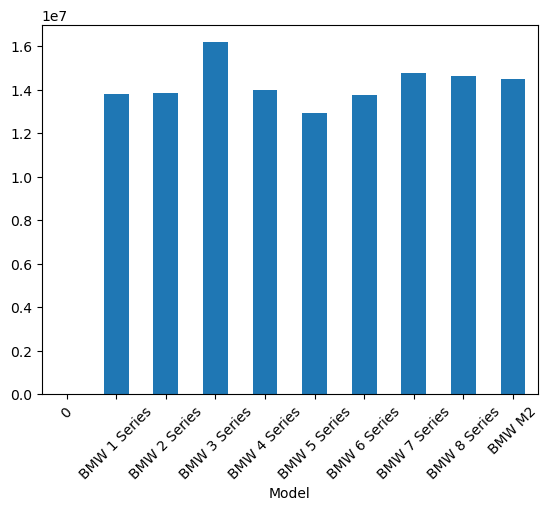

In [20]:
sales=data.groupby('Model')['Revenue'].sum().head(10)
sales.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

In [21]:
print(data.groupby('Region')['Revenue'].sum())

Region
0                       0.0
Africa           82294560.0
Asia             74287241.0
Europe           70308341.0
North America    73889127.0
South America    75285956.0
Name: Revenue, dtype: float64


<Axes: xlabel='Region'>

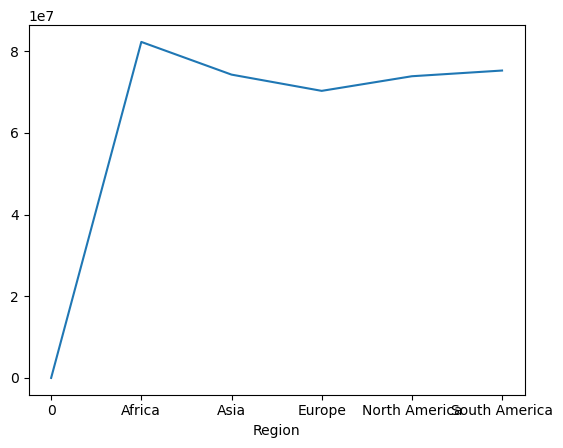

In [22]:
Region_Sales=data.groupby('Region')['Revenue'].sum()
Region_Sales.plot(kind='line')

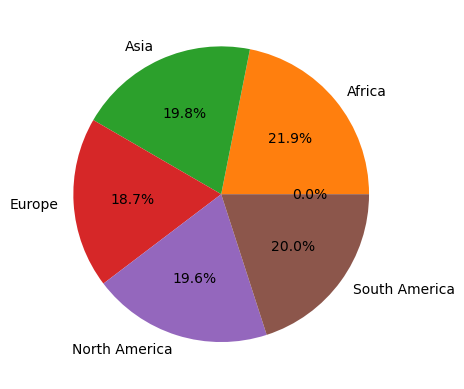

In [25]:
region_sales = data.groupby('Region')['Revenue'].sum()
region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.show()

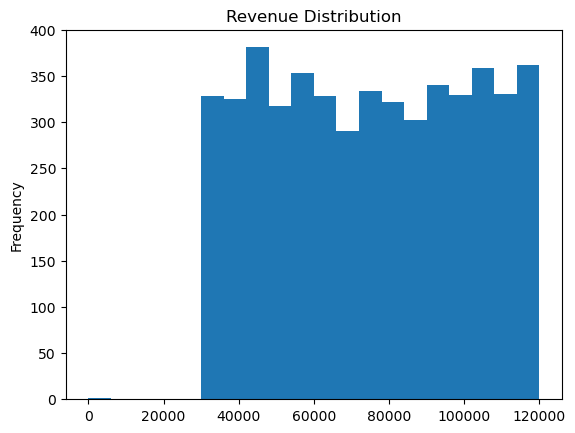

In [26]:
data['Revenue'].plot(
    kind='hist',
    bins=20
)
plt.title("Revenue Distribution")
plt.show()

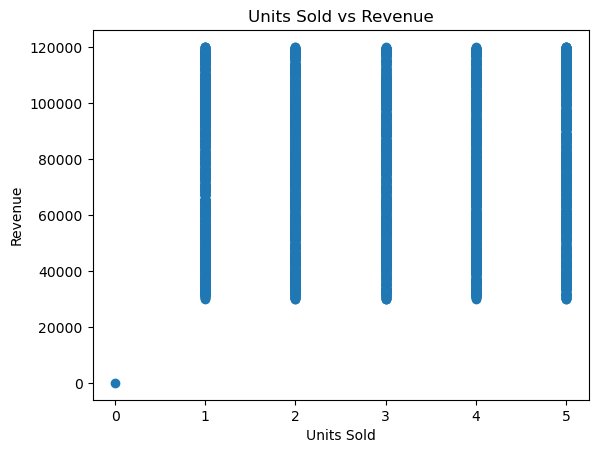

In [27]:
plt.scatter(
    data['Quantity Sold'],
    data['Revenue']
)

plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Units Sold vs Revenue")

plt.show()

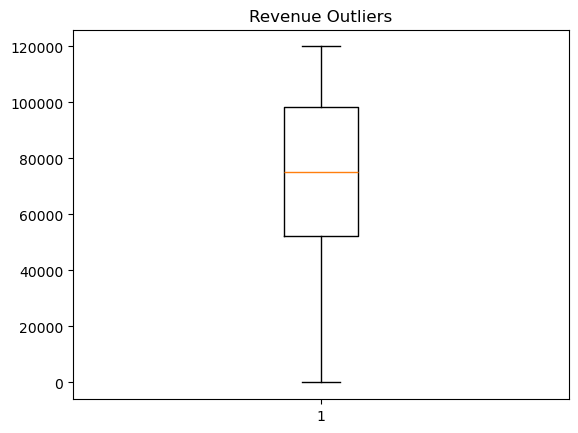

In [28]:
plt.boxplot(data['Revenue'])
plt.title("Revenue Outliers")
plt.show()

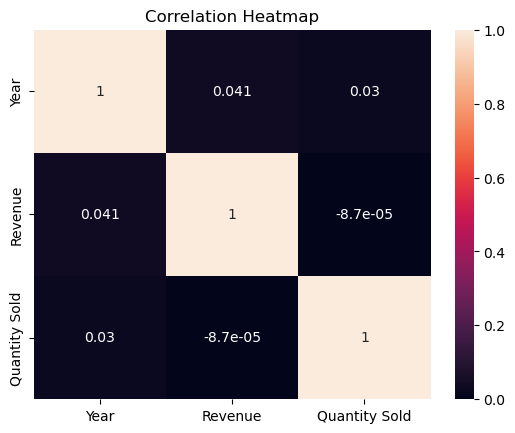

In [29]:
corr=data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
data.to_csv("BMW_Clean_Data.csv",index=False)